# Bubble chart: Access to clean fuels vs GDP per capita (2023)

In this notebook we recreate an Our World in Data (OWID)-style bubble chart showing the relationship between access to clean fuels for cooking and GDP per capita (2023). We use a CSV snapshot prepared from OWID and visualize it in both **Matplotlib** (static) and **Plotly** (interactive).

Goals:
- Load a CSV snapshot that already combines clean fuels (%) and GDP per capita.
- Prepare tidy data for a single year (2023).
- Create a static Matplotlib bubble chart.
- Create an interactive Plotly version with hover tooltips.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Matplotlib style settings (OWID-inspired)
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [24]:
# Load snapshot for clean fuels vs GDP per capita

data_path = "data/clean_fuels_vs_gdp_per_capita.csv"
df = pd.read_csv(data_path)
df.head()


,Entity,Code,Year,Access to clean fuels and technologies for cooking,GDP per capita,Population,World region according to OWID
0,Afghanistan,AFG,2000,6.20,1617.8264,20130334.0,Asia
1,Afghanistan,AFG,2001,7.10,1454.1108,20284303.0,Asia
2,Afghanistan,AFG,2002,8.30,1774.3087,21378123.0,Asia
3,Afghanistan,AFG,2003,9.35,1815.9282,22733053.0,Asia
4,Afghanistan,AFG,2004,10.80,1776.9182,23560656.0,Asia


In [25]:
# Inspect columns and basic info

print(df.columns)
print()
print(df.info())


Index(['Entity', 'Code', 'Year',
       'Access to clean fuels and technologies for cooking', 'GDP per capita',
       'Population', 'World region according to OWID'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8010 entries, 0 to 8009
Data columns (total 7 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Entity                                              8010 non-null   object 
 1   Code                                                7295 non-null   object 
 2   Year                                                8010 non-null   int64  
 3   Access to clean fuels and technologies for cooking  5148 non-null   float64
 4   GDP per capita                                      7240 non-null   float64
 5   Population                                          7249 non-null   float64
 6   World region according to OWID                    

In [26]:
# Prepare tidy data for 2023 only

# Column names from the snapshot:
# 'Entity', 'Code', 'Year', 'Access to clean fuels and technologies for cooking', 'GDP per capita', 'Population', 'World region according to OWID'

indicator_col = "Access to clean fuels and technologies for cooking"
gdp_col = "GDP per capita"

# Keep only 2023 rows and drop entries with missing key values
df_2023 = df[df["Year"] == 2023].copy()
df_2023 = df_2023.dropna(subset=[indicator_col, gdp_col])

# For the workshop, we may want to focus on a subset of countries;
# you can uncomment and adjust the filter below if desired.
# country_codes = ["THA", "VNM", "IDN", "KHM", "MMR", "LAO"]
# df_2023 = df_2023[df_2023["Code"].isin(country_codes)].copy()

# Simple sanity checks
assert df_2023["Year"].nunique() == 1, "Filtered data should contain only 2023"

# Rename columns for plotting convenience
df_2023 = df_2023.rename(columns={indicator_col: "clean_fuels_pct", gdp_col: "gdp_per_capita"})

# Ensure numeric types
df_2023["clean_fuels_pct"] = df_2023["clean_fuels_pct"].astype(float)
df_2023["gdp_per_capita"] = df_2023["gdp_per_capita"].astype(float)

# Use population to scale bubble sizes (optional)
if "Population" in df_2023.columns:
    df_2023["Population"] = df_2023["Population"].astype(float)

df_2023.head()


,Entity,Code,Year,clean_fuels_pct,gdp_per_capita,Population,World region according to OWID
23,Afghanistan,AFG,2023,38.6,1983.8126,41454762.0,Asia
91,Albania,ALB,2023,86.1,20481.0350,2811660.0,Europe
126,Algeria,DZA,2023,99.7,15159.3240,46164222.0,Africa
195,Andorra,AND,2023,100.0,64631.2970,80869.0,Europe
230,Angola,AGO,2023,50.2,8788.2610,36749909.0,Africa


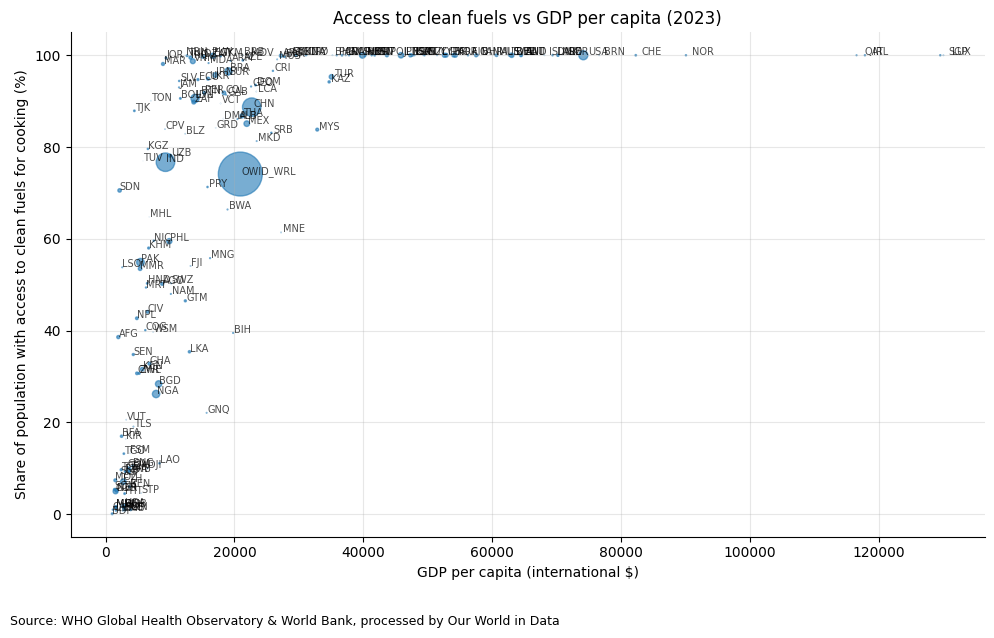

In [27]:
# Matplotlib bubble chart: clean fuels vs GDP per capita (2023)

fig, ax = plt.subplots()

# Choose bubble sizes; scale population if available
if "Population" in df_2023.columns:
    # Scale population to reasonable bubble sizes
    size = df_2023["Population"] / df_2023["Population"].max() * 1000
else:
    size = 200  # constant size

scatter = ax.scatter(
    df_2023["gdp_per_capita"],
    df_2023["clean_fuels_pct"],
    s=size,
    alpha=0.6,
)

ax.set_xlabel("GDP per capita (international $)")
ax.set_ylabel("Share of population with access to clean fuels for cooking (%)")
ax.set_title("Access to clean fuels vs GDP per capita (2023)")

# Optionally annotate a few points (e.g. selected countries)
for _, row in df_2023.iterrows():
    ax.text(
        row["gdp_per_capita"] * 1.01,
        row["clean_fuels_pct"],
        row["Code"],
        fontsize=7,
        alpha=0.7,
    )

plt.figtext(
    0.01,
    -0.05,
    "Source: WHO Global Health Observatory & World Bank, processed by Our World in Data",
    ha="left",
    fontsize=9,
)

plt.tight_layout()
plt.show()


## Interactive Plotly version

Below we create an interactive bubble chart using Plotly. You can hover over each point to see the country name and exact values for clean fuels access, GDP per capita, and population, and zoom or pan in the chart.


In [28]:
# Improved Plotly bubble chart: closer to OWID spec

# We assume df_2023 is already prepared and contains columns:
# 'Entity', 'Code', 'Year', 'clean_fuels_pct', 'gdp_per_capita', 'Population',
# and 'World region according to OWID'.

color_col = "World region according to OWID" if "World region according to OWID" in df_2023.columns else None

# Custom color map approximating OWID continent colors
color_discrete_map = {
    "North America": "rgb(229, 110, 90)",
    "South America": "rgb(136, 48, 57)",
    "Africa": "rgb(162, 85, 156)",
    "Europe": "rgb(76, 106, 156)",
    "Asia": "rgb(9, 132, 126)",
    "Oceania": "rgb(56, 170, 186)",
}

# Scale population into a friendlier range and create labels for larger countries
if "Population" in df_2023.columns:
    df_2023["pop_millions"] = df_2023["Population"] / 1_000_000
    # Always-visible labels use the full country name from "Entity"
    df_2023["label"] = df_2023["Entity"].where(df_2023["Population"] >= 600_000)
    size_arg = "pop_millions"
    text_arg = "label"
else:
    size_arg = None
    text_arg = None

fig_owid = px.scatter(
    df_2023,
    x="gdp_per_capita",
    y="clean_fuels_pct",
    size=size_arg,
    color=color_col,
    hover_name="Entity",
    title="Access to clean fuels for cooking vs. GDP per capita, 2023",
    custom_data=["Population", "Year"],
    color_discrete_map=color_discrete_map if color_col is not None else None,
    size_max=60,
    text=text_arg,
)

# Axes: log scale for GDP, approximate OWID tick values and ranges
fig_owid.update_xaxes(
    type="log",
    tickvals=[2000, 5000, 10000, 20000, 50000, 100000],
    ticktext=["2k", "5k", "10k", "20k", "50k", "100k"],
)

fig_owid.update_yaxes(
    range=[20, 100],
    tickvals=[20, 40, 60, 80, 100],
)

# Layout: white background, light grid, legend on the right
fig_owid.update_layout(
    template="plotly_white",
    xaxis_title="GDP per capita (international-$ in 2021 prices; logarithmic scale)",
    yaxis_title="Access to clean fuels and technologies for cooking (%)",
    legend=dict(orientation="v", x=1.02, y=1),
)

fig_owid.update_xaxes(showgrid=True, gridcolor="rgba(0,0,0,0.1)")
fig_owid.update_yaxes(showgrid=True, gridcolor="rgba(0,0,0,0.1)")

# Hover template: Name, Year, GDP per capita, Clean fuels, Population
fig_owid.update_traces(
    hovertemplate=""
    "<b>%{hovertext}</b><br>"  # Entity
    "Year: %{customdata[1]}<br>"
    "Access to clean fuels: %{y:.1f}%<br>"
    "GDP per capita: %{x:,.0f}<br>"
    "Population: %{customdata[0]:,.0f}<extra></extra>",
    textposition="top center",
    textfont=dict(size=8),
)

# Note about bubble sizes
fig_owid.add_annotation(
    xref="paper",
    yref="paper",
    x=0.0,
    y=-0.2,
    text="Circles sized by population (largest: China, India)",
    showarrow=False,
    font=dict(size=9),
)

fig_owid.show()

Checklist:
1. OWID chart spec:
    - data subset: Year = 2023 (We're comparing 'Access to clean fuels for cooking vs GDP per capita, 2023')
    - all countries are visible
    - missing data are excluded
    - GDP per capita is plotted on a logarithmic axis
    - Clean fuels (%) is 0-100
    - X-axis title and unit: GDP per capita (international-$ in 2021 prices; plotted on a logarithmic axis)
    - Y-axis title and unit: Access to clean fuels and technologies for cooking
    - X-axis range: $2000, $5000, $10,000, $20,000, $50,000 and $100,000
    - Y-axis range: 20%, 40%, 60%, 80%, 100%
    - Color is mapped to continent (North America, South America, Africa, Europe, Asia, Oceania)
    - Bubble sized by population
    - OWID shows a legend by continents
    - Labels for countries with population size larger than 1 million (to reduce clutter)
    - Hover fields: Name, Year, GDP per capita ($), Access to clean fuels and technologies for cooking (%), Population (number of people)
    - Default zoom extent: Yes
    - Reference lines or annotations (omit subtitle to reduce clutter).
2. Lock data parity:
    - filter to 2023 (done)
    - use all countries OWID does by default
    - columns confirmed
3. Match scales and axes:
    - X-axis: OWID uses log scale, set: `fig.update_xaxes(type="log")`
    - X-axis range: $2000, $5000, $10,000, $20,000, $50,000 and $100,000
    - Y-axis range: 20%, 40%, 60%, 80%, 100%
    - OWID Title: "Access to clean fuels for cooking vs. GDP per capita, 2023"
4. Match color and size encoding:
    - OWID colors by continent: color="World continents according to OWID"
    - Custom color sequence: (North America, rgb(229, 110, 90); South America, rgb(136, 48, 57); Africa, rgb(162, 85, 156); Europe, rgb(76, 106, 156); Asia, rgb(9, 132, 126); Oceania, rgb(56, 170, 186))
    - size="Population"
5. Fine-tune layout (background, grid, legend)
    - template / background: fig.update_layout(template="plotly_white")
    - gridlines & spines: 
        - fig.update_xaxes(showgrid=True, gridcolor="rgba(0,0,0,0.1)")
        - fig.update_yaxes(showgrid=True, gridcolor="rgba(0,0,0,0.1)")
    - legend: fig.update_layout(legend=dict(orientation="v", x=1.02, y=1))
    - legend colored by continents
6. Customize hover tooltips
    - OWID hover cards: Name, Year, GDP per capita ($), Access to clean fuels and technologies for cooking (%), Population (number of people)
    ```
        fig.update_traces(
        hovertemplate=(
            "<b>%{hovertext}</b><br>"  # Entity
            "Clean fuels: %{y:.1f}%<br>"
            "GDP per capita: %{x:,.0f}<br>"
            "Population: %{marker.size:.0f}<extra></extra>"
        )
    )
    ```
7. Final polish: labels and annotations
    - note: "Circles sized by Population" (Largest circles: China, India: 1.4B )

## Licensing, attribution, and how to obtain the data

- Data and original interactive chart: Our World in Data, "Access to clean fuels for cooking vs. GDP per capita" (`access-to-clean-fuels-for-cooking-vs-gdp-per-capita`).
- Clean fuels indicator source: World Health Organization – Global Health Observatory (GHO).
- GDP per capita source: World Bank, processed by Our World in Data.
- OWID and its code/visualizations are released under [Creative Commons BY](https://ourworldindata.org/grapher/access-to-clean-fuels-for-cooking-vs-gdp-per-capita#reuse); original providers retain their own licenses.

To obtain the CSV and use it in this notebook:
1. Open the [OWID chart page](https://ourworldindata.org/grapher/access-to-clean-fuels-for-cooking-vs-gdp-per-capita?tab=table&time=2023).
2. Click **"Download"** (or the **"Data"** tab) and choose **CSV** or copy the table.
3. Save the filtered table as `data/clean_fuels_vs_gdp_per_capita.csv` in the same folder as this notebook (i.e. `notebooks/data/clean_fuels_vs_gdp_per_capita.csv`).
4. Re-run the notebook; it will load from this local file.
